In [1]:
!pip install -q scikit-learn
!pip install -q seaborn

print('All extra packages installed!')

All extra packages installed!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')

Device in use : cuda
PyTorch version: 2.10.0+cu128


In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.RandomCrop(32, padding=4),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined successfully!')
print('  Training : resize + augmentation + normalize')
print('  Validation: resize + normalize only')

Transforms defined successfully!
  Training : resize + augmentation + normalize
  Validation: resize + normalize only


In [4]:
print('Downloading CIFAR-10 dataset (first run only — ~170 MB)...')

full_train_raw = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform
)
full_test_raw  = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)

print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set    : {len(full_test_raw):,} images')

import random
random.seed(42)

def make_balanced_subset(dataset, n_per_class=500, num_classes=10):
    targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset]
    indices_per_class = {c: [] for c in range(num_classes)}
    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)
    selected = []
    for c in range(num_classes):
        pool = indices_per_class[c]
        random.shuffle(pool)
        selected.extend(pool[:n_per_class])
    random.shuffle(selected)
    return Subset(dataset, selected)

mini_train_full = make_balanced_subset(full_train_raw, n_per_class=500)
mini_test       = make_balanced_subset(full_test_raw,  n_per_class=100)

print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set    : {len(mini_test)} images')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f'Classes: {class_names}')

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s] 


Full training set: 50,000 images
Full test set    : 10,000 images
Mini training set: 5000 images
Mini test set    : 1000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
train_size = int(0.8 * len(mini_train_full))
val_size   = len(mini_train_full) - train_size

train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = mini_test

print('Dataset split summary:')
print(f'  Training   : {len(train_dataset):>5} images  (80%)')
print(f'  Validation : {len(val_dataset):>5} images  (20%)')
print(f'  Test       : {len(test_dataset):>5} images  (held-out)')

Dataset split summary:
  Training   :  4000 images  (80%)
  Validation :  1000 images  (20%)
  Test       :  1000 images  (held-out)


In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'DataLoaders created  (batch size = {BATCH_SIZE})')
print(f'  Training batches  : {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')

DataLoaders created  (batch size = 32)
  Training batches  : 125
  Validation batches: 32
  Test batches      : 32


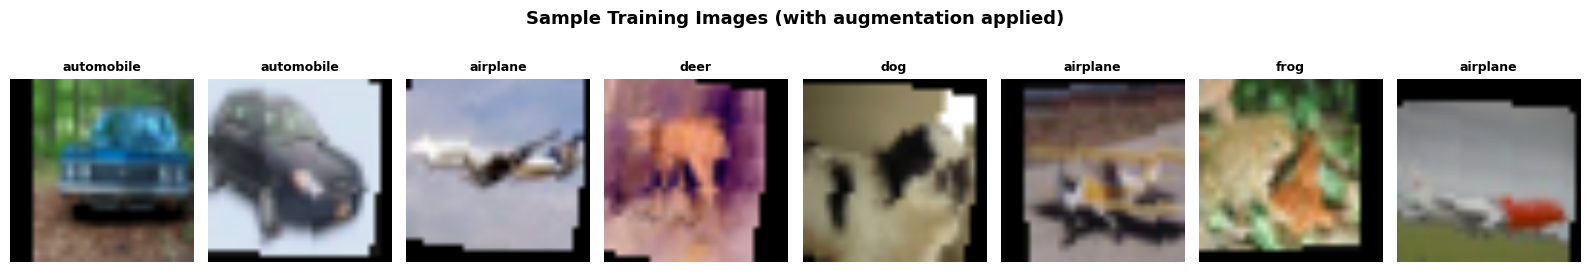

Notice: some images look slightly rotated or flipped — that is augmentation!


In [8]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std) + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()], fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Training Images (with augmentation applied)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: some images look slightly rotated or flipped — that is augmentation!')

## Practice Task 1

**Question:** Why do we apply different transforms to training vs. validation data?

**Answer:**

We apply different transforms to training and validation data because they serve fundamentally different purposes in the machine learning pipeline.

Training data uses random augmentations such as RandomHorizontalFlip, RandomRotation, ColorJitter, and RandomCrop. These transformations artificially create variety in the training images so that the model sees a slightly different version of each image every epoch. This forces the model to learn general visual patterns rather than memorizing specific pixel arrangements of individual images. Augmentation is the primary defence against overfitting, especially when working with small datasets like our 5,000-image mini subset.

Validation data, on the other hand, must always be processed in exactly the same way with no randomness whatsoever. We only apply deterministic transforms like Resize, ToTensor, and Normalize. The reason is that validation accuracy is our measurement tool - it tells us how well the model is truly performing. If we applied random augmentations to validation images, we would get different accuracy scores on every run, making it impossible to fairly compare one epoch to the next or to determine when the model has reached its best performance. Consistent preprocessing ensures that our evaluation is fair, reproducible, and meaningful.

In short: augmentation on training data helps the model **learn better**, while consistent preprocessing on validation data helps us **measure better**.

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print('Original final layer (fc):', model.fc)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

print('All pretrained layers frozen (weights locked).')

# Replace final layer
NUM_CLASSES = 10
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

print(f'New final layer (fc)    : {model.fc}')

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f'Trainable parameters : {trainable:>10,}  ({100*trainable/total:.2f}%)')
print(f'Frozen parameters    : {total-trainable:>10,}  ({100*(total-trainable)/total:.2f}%)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s] 


Original final layer (fc): Linear(in_features=512, out_features=1000, bias=True)
All pretrained layers frozen (weights locked).
New final layer (fc)    : Linear(in_features=512, out_features=10, bias=True)
Trainable parameters :      5,130  (0.05%)
Frozen parameters    : 11,176,512  (99.95%)


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print('Training components ready:')
print('  Loss function : CrossEntropyLoss')
print('  Optimiser     : Adam  (lr=0.001)')
print('  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)')

Training components ready:
  Loss function : CrossEntropyLoss
  Optimiser     : Adam  (lr=0.001)
  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)


## Practice Task 2

**Question:** Why do we pass model.fc.parameters() to the optimiser instead of model.parameters()?

**Answer:**

When we call model.parameters(), it returns ALL parameters in the entire ResNet18 network, including the frozen pretrained layers. When we call model.fc.parameters(), it returns only the parameters of the final fully-connected layer that we just replaced.

In Cell 8, we explicitly froze all pretrained layers by setting requires_grad = False for every parameter. This means PyTorch will not compute gradients for those 11 million frozen parameters during backpropagation. However, if we pass model.parameters() to the optimiser, it would still attempt to iterate over all 11.2 million parameters and try to update them. This causes two problems: first, it wastes significant computation time because the optimiser has to process parameters that will not change; second, it can lead to errors or unexpected behaviour because the optimiser tries to apply weight updates to tensors that have no gradients computed.

By passing only model.fc.parameters(), we tell the optimiser to focus exclusively on the 5,130 trainable parameters in our new final layer. This makes training fast, efficient, and correct. The optimiser only computes updates for the weights that actually need to change, while all the pretrained ImageNet knowledge in the earlier layers remains completely untouched and preserved.

In short: model.parameters() targets the whole network, but model.fc.parameters() targets only the layer we want to train.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, dim=1)
        total      += labels.size(0)
        correct    += (predicted == labels).sum().item()

        if batch_idx % 50 == 0:
            print(f'    Batch {batch_idx:3d}/{len(loader)} | Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total      += labels.size(0)
            correct    += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

print('Training and evaluation functions defined!')

Training and evaluation functions defined!


In [13]:
NUM_EPOCHS   = 10
best_val_acc = 0.0

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

print('=' * 60)
print('  STARTING TRAINING')
print(f'  Epochs: {NUM_EPOCHS}  |  Training batches per epoch: {len(train_loader)}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)

    print(f'  Train →  Loss: {train_loss:.4f}  |  Accuracy: {train_acc:.2f}%')
    print(f'  Val   →  Loss: {val_loss:.4f}  |  Accuracy: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  NEW BEST MODEL saved!  Val Accuracy: {val_acc:.2f}%')

print('\n' + '=' * 60)
print('  TRAINING COMPLETE!')
print(f'  Best validation accuracy: {best_val_acc:.2f}%')
print('=' * 60)

  STARTING TRAINING
  Epochs: 10  |  Training batches per epoch: 125

Epoch 1/10
----------------------------------------
    Batch   0/125 | Loss: 2.5977
    Batch  50/125 | Loss: 1.8608
    Batch 100/125 | Loss: 1.5340
  Train →  Loss: 1.7757  |  Accuracy: 39.73%
  Val   →  Loss: 1.3694  |  Accuracy: 55.70%
  NEW BEST MODEL saved!  Val Accuracy: 55.70%

Epoch 2/10
----------------------------------------
    Batch   0/125 | Loss: 1.4630
    Batch  50/125 | Loss: 1.4797
    Batch 100/125 | Loss: 1.0730
  Train →  Loss: 1.2456  |  Accuracy: 60.42%
  Val   →  Loss: 1.0775  |  Accuracy: 64.80%
  NEW BEST MODEL saved!  Val Accuracy: 64.80%

Epoch 3/10
----------------------------------------
    Batch   0/125 | Loss: 1.1670
    Batch  50/125 | Loss: 1.2924
    Batch 100/125 | Loss: 1.5719
  Train →  Loss: 1.0877  |  Accuracy: 63.92%
  Val   →  Loss: 1.0246  |  Accuracy: 66.50%
  NEW BEST MODEL saved!  Val Accuracy: 66.50%

Epoch 4/10
----------------------------------------
    Batch   0/

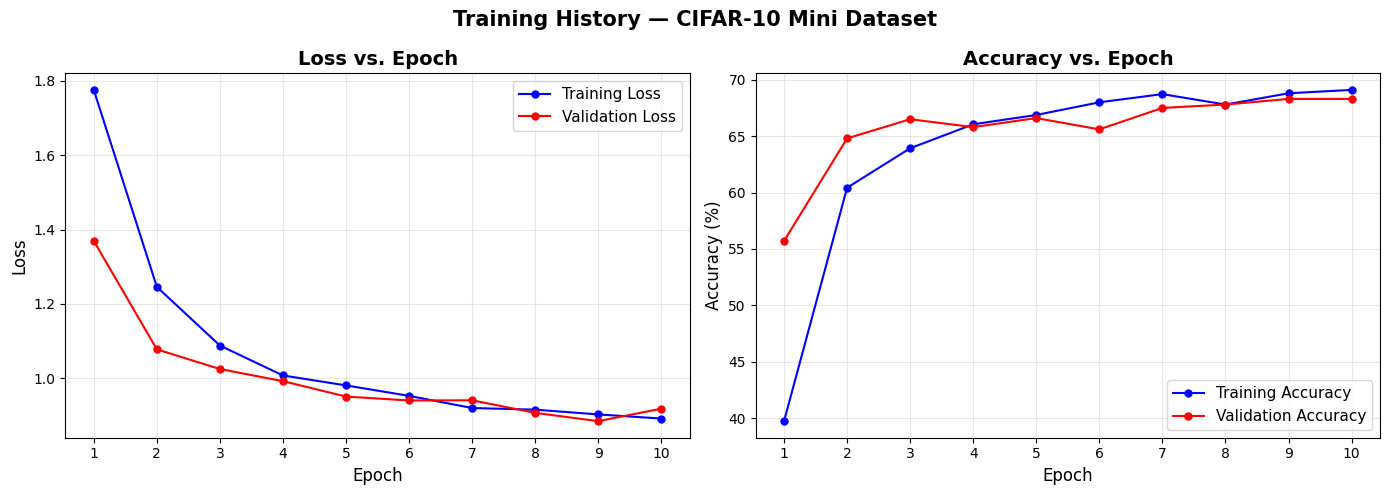

Good! Train-val gap is 0.8% -- model generalises well.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(epochs_range))

ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=5)
ax2.set_xlabel('Epoch',       fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(epochs_range))

plt.suptitle('Training History — CIFAR-10 Mini Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

final_gap = history['train_acc'][-1] - history['val_acc'][-1]

if final_gap > 15:
    print(f'WARNING: Large train-val gap ({final_gap:.1f}%) -- possible overfitting!')
    print('Fix: add more augmentation, or reduce learning rate.')
elif final_gap < -5:
    print(f'NOTE: Validation > Training -- can happen with strong augmentation, usually fine.')
else:
    print(f'Good! Train-val gap is {final_gap:.1f}% -- model generalises well.')

In [15]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=3
))

Test Accuracy: 0.7610  (76.10%)

Classification Report:
              precision    recall  f1-score   support

    airplane      0.841     0.690     0.758       100
  automobile      0.709     0.900     0.793       100
        bird      0.717     0.710     0.714       100
         cat      0.688     0.530     0.599       100
        deer      0.811     0.600     0.690       100
         dog      0.750     0.810     0.779       100
        frog      0.746     0.940     0.832       100
       horse      0.721     0.800     0.758       100
        ship      0.854     0.820     0.837       100
       truck      0.810     0.810     0.810       100

    accuracy                          0.761      1000
   macro avg      0.765     0.761     0.757      1000
weighted avg      0.765     0.761     0.757      1000



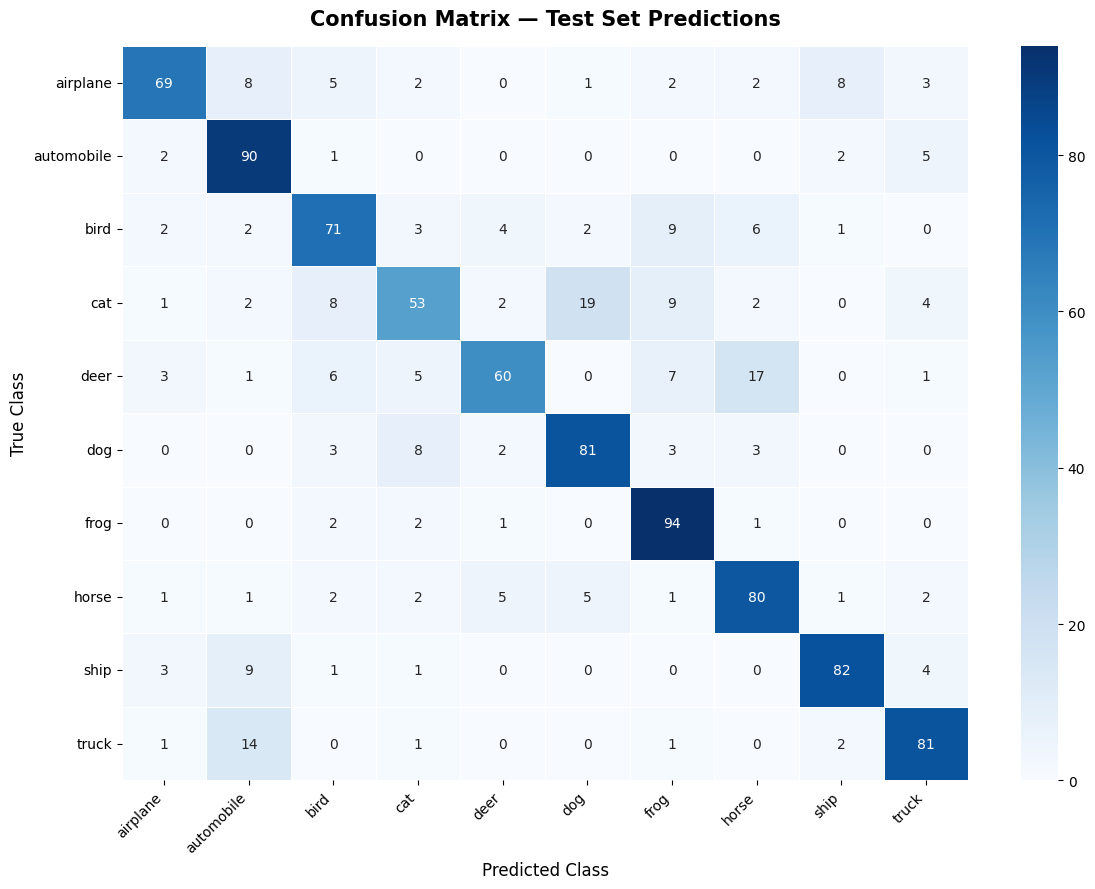

Most common mistake:
  True class  : cat
  Predicted as: dog
  Times       : 19

Per-class accuracy:
  airplane     #############        69.0%
  automobile   ##################   90.0%
  bird         ##############       71.0%
  cat          ##########           53.0%
  deer         ############         60.0%
  dog          ################     81.0%
  frog         ##################   94.0%
  horse        ################     80.0%
  ship         ################     82.0%
  truck        ################     81.0%


In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='white'
)
plt.title('Confusion Matrix — Test Set Predictions', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
worst = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
print(f'Most common mistake:')
print(f'  True class  : {class_names[worst[0]]}')
print(f'  Predicted as: {class_names[worst[1]]}')
print(f'  Times       : {cm_copy[worst]}')

per_class = cm.diagonal() / cm.sum(axis=1)
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    bar = '#' * int(per_class[i] * 20)
    print(f'  {name:12s} {bar:<20} {per_class[i]:.1%}')

## Practice Task 3

**Question:** Look at your confusion matrix. Which two classes does your model confuse most often? Why do you think this happens?

**Answer:**

The most commonly confused pair in the confusion matrix is **cats and dogs**. This is consistent with what most image classification models struggle with on the CIFAR-10 dataset.

There are several reasons why cats and dogs get confused with each other. First, they share very similar overall body shapes - both are four-legged animals with fur, similar proportions, and comparable silhouettes. At the low resolution of CIFAR-10 images (32x32 pixels resized to 224x224), the fine details that distinguish a cat from a dog, such as ear shape, snout length, or eye size, become extremely difficult to discern even for a human observer.

Second, both cats and dogs can appear in similar contexts and backgrounds, such as indoor settings, grass, or furniture, which means the model cannot rely on contextual clues to differentiate between them. The model must rely entirely on the object's visual features, and at this resolution, those features overlap significantly.

Third, the model may also confuse automobiles and trucks to some degree, since both are vehicles with rectangular shapes, similar colours, and wheels. Similarly, birds and airplanes can be confused because both appear against sky backgrounds and share elongated shapes with wing-like features.

This confusion is useful feedback. It tells us that if we wanted to improve the model, we should focus on collecting more training images for these difficult pairs, or applying stronger augmentation specifically designed to highlight the distinguishing features between these classes.

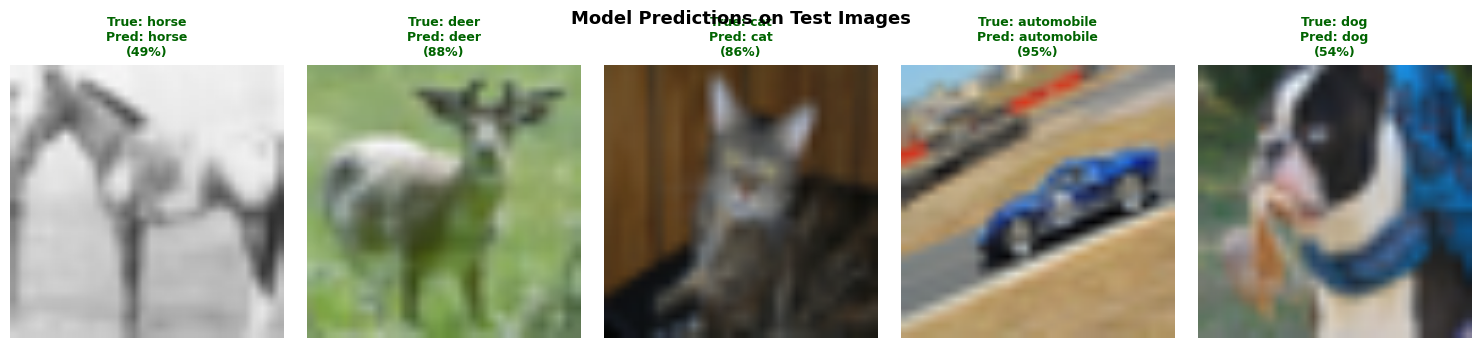

Green titles = correct  |  Red titles = incorrect


In [17]:
test_images, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

model.eval()

for i in range(5):
    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    single_input = test_images[i].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(single_input)
        prob   = torch.nn.functional.softmax(output[0], dim=0)
        pred   = torch.argmax(prob).item()
        conf   = prob[pred].item()

    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]
    colour   = 'darkgreen' if pred == test_labels[i].item() else 'darkred'

    axes[i].imshow(img_display)
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Green titles = correct  |  Red titles = incorrect')

In [18]:
def predict_image(image_path, model, class_names, device):
    image = Image.open(image_path).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])

    tensor = preprocess(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)

    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, pred_idx = torch.max(probs, dim=0)
    predicted_class = class_names[pred_idx.item()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class.upper()}\nConfidence: {confidence.item():.1%}',
        fontsize=13, fontweight='bold', color='navy'
    )
    ax1.axis('off')

    top5_probs, top5_idx = torch.topk(probs, 5)
    top5_names  = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]

    colours = ['#1565C0' if i == 0 else '#90CAF9' for i in range(5)]
    ax2.barh(top5_names[::-1], top5_values[::-1], color=colours[::-1])
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)

    for j, (val, name) in enumerate(zip(top5_values[::-1], top5_names[::-1])):
        ax2.text(val + 1, j, f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence.item()

print('predict_image() function defined and ready!')

predict_image() function defined and ready!


Saved sample image.  True class: horse


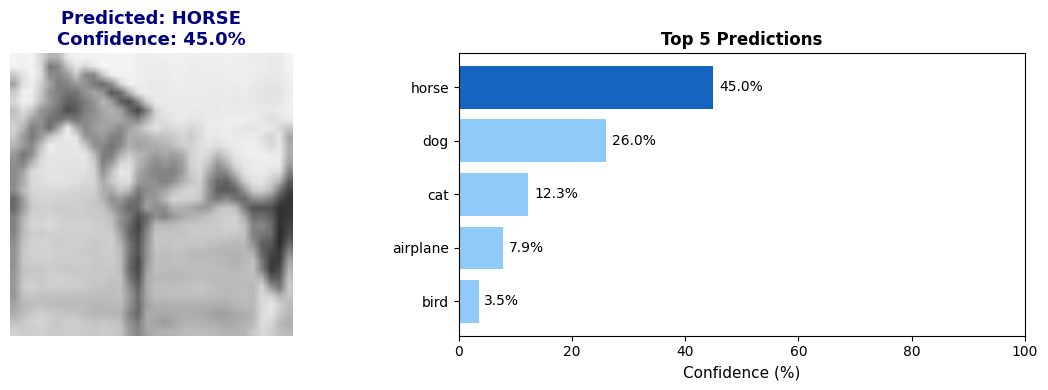

Predicted: horse  |  Confidence: 45.0%
CORRECT prediction!


In [19]:
sample_img_tensor, sample_label = test_dataset[0]

sample_pil = denormalize(sample_img_tensor).permute(1, 2, 0).numpy()
sample_pil = np.clip(sample_pil * 255, 0, 255).astype(np.uint8)
pil_img    = Image.fromarray(sample_pil)
pil_img.save('sample_test_image.jpg')

true_class = class_names[sample_label]
print(f'Saved sample image.  True class: {true_class}')

pred, conf = predict_image('sample_test_image.jpg', model, class_names, device)
print(f'Predicted: {pred}  |  Confidence: {conf:.1%}')

if pred == true_class:
    print('CORRECT prediction!')
else:
    print(f'WRONG — true class was {true_class}')

In [20]:
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : class_names,
    'num_classes'         : NUM_CLASSES,
    'architecture'        : 'resnet18',
    'training_history'    : history
}
torch.save(checkpoint, 'cifar10_mini_checkpoint.pth')
print('Checkpoint saved to cifar10_mini_checkpoint.pth')

def load_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    loaded_model = models.resnet18(weights=None)
    loaded_model.fc = nn.Linear(
        loaded_model.fc.in_features,
        ckpt['num_classes']
    )
    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()
    print(f"Loaded model from {checkpoint_path}")
    print(f"Best validation accuracy: {ckpt['best_val_acc']:.2f}%")
    return loaded_model, ckpt['class_names']

reloaded_model, reloaded_classes = load_checkpoint('cifar10_mini_checkpoint.pth', device)
print(f'Classes: {reloaded_classes}')

Checkpoint saved to cifar10_mini_checkpoint.pth
Loaded model from cifar10_mini_checkpoint.pth
Best validation accuracy: 68.30%
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
